# Do events move crime? An offline walkthrough

Part of the research sandbox: **do events change crime and 311 in the cells around them, and can
upcoming ones be flagged ahead of time?** Major pro sports are out of scope, since everyone already plans around
those. The focus is city-permitted events (street festivals, block parties, parades) and shows at smaller music
clubs. The notebook reads the outputs the event scripts already wrote and runs top to bottom in about 10 seconds.

| Step | Script | Output |
|---|---|---|
| 1 | `events_fetch.py` | raw permits, park polygons, setlist.fm pages, a Ticketmaster snapshot |
| 2 | `events_build.py` | one event table on H3 r9 cells |
| 3 | `events_impact.py` | observed vs expected crime and 311 around events (permits by day, clubs by night) |
| 4 | `events_lookahead.py` | upcoming festivals and club nights, ranked by likely extra crime |
| 5 | `events_backtest.py` | the look-ahead replayed on 2017–2025 |

### Short version
- **Street festivals raise crime where they are.**
  - About +31% in their own cells on event days, and +52% for festivals closing 5+ street segments.
  - It's mostly daytime, and it fades within two cells (~0.4 km).
  - Nothing shows on the day before, the day after, or a placebo date.
- **Club show nights run +11%, almost all of it before midnight.** Block parties run +6%.
- **Parades don't change crime.** Only police-found offenses rise, which reflects the deployment,
  not the crowd.
- **The absolute numbers are modest.**
  - A typical festival adds about half a crime over its run, and one closing 5+ segments about 2.5.
  - A club show adds about one per 18 shows, and a block party about one per 100.
- **311 barely moves:** +8% in festival cells, and nothing elsewhere.
- **The look-ahead is a short filter, not a precise ranking.**
  - Its totals are about right: 1,217 extra crimes predicted over 2017–2025, and 1,105 happened.
  - Its top decile holds 62% of the actual extra crime.
  - A festival's own history helps a little. Pub crawls are the ones that stand out.

*Numbers in the prose are from the 2026-09-26 run, which fixed a counting bug: until then, "crime" counted
cell-days with any crime rather than crimes, which understated the festival effect. The code cells recompute
everything from the saved outputs.*

In [1]:
# The notebook lives in offline_ml/ and borrows helpers from the event scripts beside it.
import logging
import sys
from datetime import date, datetime, time, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from h3.api import basic_int as h3
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize

sys.path.insert(0, str(Path.cwd()))
from config import CLEAN, EVENTS
from events_fetch import CLUBS, RAW
from events_impact import busy_cell_days, event_cell_days
from events_lookahead import OUT as LOOKAHEAD, festival_scores, load_counts

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # no "semibold" fallback notices
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_float_precision(3)
pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_width_chars(160)

# Chart palette: the validated reference palette, light surface (same as walkthrough.ipynb).
SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e4e3df"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"          # categorical slots 1-3
NEUTRAL = "#f0efec"
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "font.size": 10, "legend.frameon": False, "figure.dpi": 110,
})


def hex_map(ax, cells, colors, edge=SURFACE, lw=0.4):
    """Draw H3 cells (int ids) as polygons, lng/lat with Chicago's aspect ratio."""
    polys = [[(lng, lat) for lat, lng in h3.cell_to_boundary(int(c))] for c in cells]
    ax.add_collection(PolyCollection(polys, facecolors=colors, edgecolors=edge, linewidths=lw))
    ax.autoscale_view()
    ax.set_aspect(1 / np.cos(np.radians(41.84)))
    ax.axis("off")


def forest(ax, labels, est, lo, hi, placebo=None, color=BLUE):
    """Ratios with 90% intervals, first label on top. Hollow gray diamonds mark the placebo date."""
    y = np.arange(len(labels))[::-1]
    ax.hlines(y, lo, hi, color=color, lw=3)
    ax.plot(est, y, "o", color=color, ms=7, mec=SURFACE, mew=1.5, label="event days")
    if placebo is not None:
        ax.plot(placebo, y - 0.3, "D", mfc="none", mec=MUTED, ms=5, mew=1.2, label="placebo date, 5 weeks later")
    ax.axvline(1, color=INK_2, lw=1)
    ax.set_yticks(y, labels)
    ax.grid(axis="y", visible=False)


events = pl.read_parquet(EVENTS / "events.parquet")
cells = pl.read_parquet(EVENTS / "event_cells.parquet")
held = events.filter(pl.col("status") == "held")
summary = pl.concat([pl.read_csv(EVENTS / "impact" / "summary.csv"),
                     pl.read_csv(EVENTS / "impact" / "summary_clubs.csv")])


def pick(group, outcome="crime", ring=0, timing="event"):
    """One pooled result from events_impact.py's summaries."""
    return summary.filter((pl.col("group") == group) & (pl.col("outcome") == outcome)
                          & (pl.col("ring") == ring) & (pl.col("timing") == timing)).row(0, named=True)

## 1. What counts as an event

| Source | What it gives | Limits |
|---|---|---|
| CDOT street-use permits | festivals, block parties, parades, runs, rallies since 2014, with a point per closed street segment | whole days, no start times |
| Park District event permits | events in parks, with a size level (6 = 10,000+) | one row per facility per day, and dates include setup and teardown |
| setlist.fm | shows at 20 small clubs since 2014, one setlist per act | 1,440 requests a day, and partial coverage |
| Ticketmaster | upcoming shows with start times | no history at all, and some venue coordinates are wrong |

Metro/Smartbar and House of Blues were left out: together they're ~17,500 setlists, days of setlist.fm quota.
Every event gets the r9 cells it touches:
- **CDOT permits:** each closed segment's point.
- **Park permits:** the park's polygon.
- **Clubs:** the club's address, from the Census geocoder.

┌───────────┬────────────────────┬───────┬─────────┬────────────┬────────────┐
│ source    ┆ category           ┆ held  ┆ planned ┆ multi_week ┆ first      │
│ ---       ┆ ---                ┆ ---   ┆ ---     ┆ ---        ┆ ---        │
│ str       ┆ str                ┆ u32   ┆ u32     ┆ u32        ┆ date       │
╞═══════════╪════════════════════╪═══════╪═════════╪════════════╪════════════╡
│ cdot      ┆ assembly           ┆ 554   ┆ 4       ┆ 4          ┆ 2014-02-15 │
│ cdot      ┆ athletic           ┆ 1369  ┆ 36      ┆ 7          ┆ 2014-01-01 │
│ cdot      ┆ block_party        ┆ 47723 ┆ 363     ┆ 1          ┆ 2014-01-16 │
│ cdot      ┆ festival           ┆ 4373  ┆ 102     ┆ 550        ┆ 2014-01-20 │
│ cdot      ┆ parade             ┆ 3025  ┆ 18      ┆ 1          ┆ 2014-01-01 │
│ park      ┆ park_athletic      ┆ 2450  ┆ 0       ┆ 71         ┆ 2014-01-01 │
│ park      ┆ park_commemorative ┆ 471   ┆ 0       ┆ 0          ┆ 2014-04-20 │
│ park      ┆ park_corporate     ┆ 1391  ┆ 0       ┆

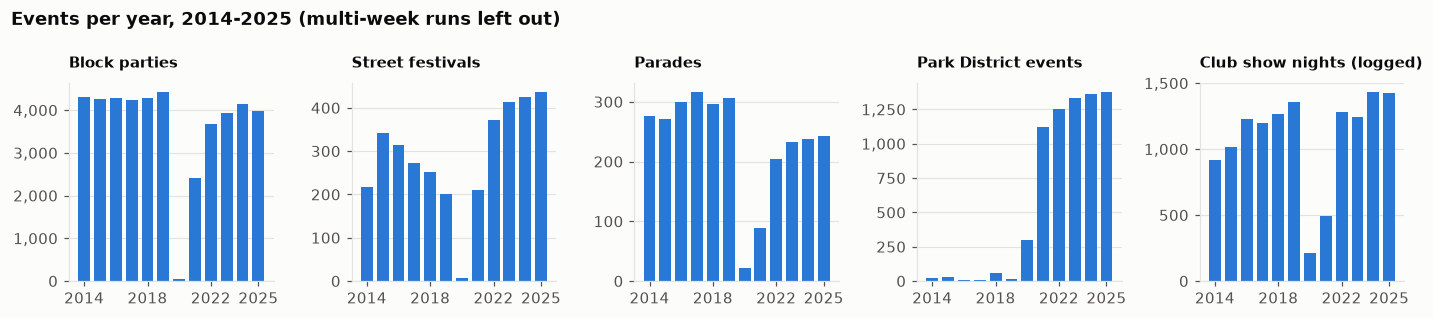

In [2]:
print(events.group_by("source", "category").agg(
    held=(pl.col("status") == "held").sum(), planned=(pl.col("status") == "planned").sum(),
    multi_week=pl.col("long_run").sum(), first=pl.col("start_date").min()).sort("source", "category"))

panels = [("block_party", "Block parties"), ("festival", "Street festivals"), ("parade", "Parades"),
          ("park_event", "Park District events"), ("club_show", "Club show nights (logged)")]
per_year = (held.filter(~pl.col("long_run") & (pl.col("start_date") < pl.date(2026, 1, 1)))
            .group_by("category", year=pl.col("start_date").dt.year()).len())
fig, axes = plt.subplots(1, 5, figsize=(13, 2.9), sharex=True)
for ax, (cat, title) in zip(axes, panels):
    d = per_year.filter(pl.col("category") == cat).sort("year")
    ax.bar(d["year"], d["len"], color=BLUE, width=0.75)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([2014, 2018, 2022, 2025])
    ax.grid(axis="x", visible=False)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
fig.suptitle("Events per year, 2014-2025 (multi-week runs left out)", x=0.01, ha="left", fontweight="semibold")
fig.tight_layout()

- **2020 is COVID:** festivals, parades and block parties nearly vanish.
- **The Park District jump in 2021 is a change in its categories, not in events.**
  - Before 2020, its only general event category was "Festival/Performance/12,001+", which covered just the
    biggest events.
  - The size-level categories ("Event 1" through "Event 6") start in 2020–21.
- **The club series is what setlist.fm users happened to log,** not a full calendar (section 2).

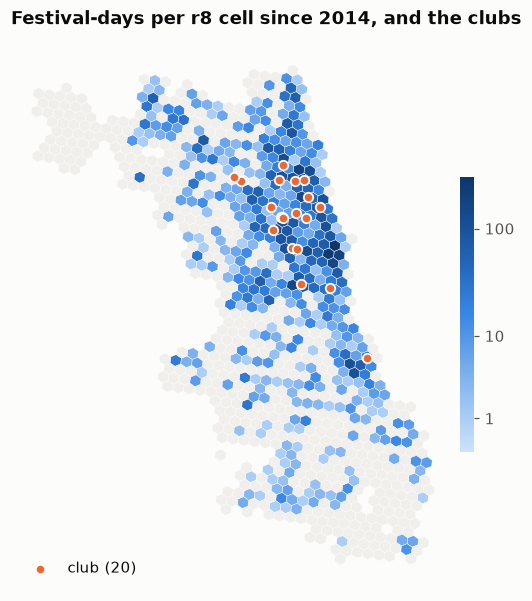

In [3]:
# Where festivals happen: festival-days per r8 cell, with the 20 clubs on top.
city = pl.read_parquet(CLEAN / "crimes.parquet", columns=["h3_r8"]).drop_nulls().unique()
fest_days = (event_cell_days(held.filter((pl.col("category") == "festival") & ~pl.col("long_run")), cells)
             .with_columns(h3_r8=pl.col("h3_r9").map_elements(lambda c: h3.cell_to_parent(c, 8), return_dtype=pl.Int64))
             .select("event_id", "date", "h3_r8").unique().group_by("h3_r8").len())
grid = city.join(fest_days, on="h3_r8", how="left").with_columns(pl.col("len").fill_null(0))
v = np.log1p(grid["len"].to_numpy())
colors = [SEQ_BLUE(x / v.max()) if n else NEUTRAL for n, x in zip(grid["len"], v)]

fig, ax = plt.subplots(figsize=(6.2, 7.2))
hex_map(ax, grid["h3_r8"], colors, lw=0.3)
ax.scatter([c[4] for c in CLUBS], [c[3] for c in CLUBS], s=38, color=ORANGE, edgecolor=SURFACE,
           linewidth=1.2, zorder=3, label="club (20)")
ax.set_title("Festival-days per r8 cell since 2014, and the clubs")
ax.legend(loc="lower left")
sm = plt.cm.ScalarMappable(cmap=SEQ_BLUE, norm=Normalize(0, v.max()))
cb = fig.colorbar(sm, ax=ax, shrink=0.45, pad=0.01)
ticks = [t for t in (1, 10, 100, 1000) if np.log1p(t) <= v.max()]
cb.set_ticks([np.log1p(t) for t in ticks])
cb.set_ticklabels([f"{t:,}" for t in ticks])
cb.outline.set_visible(False)

Festivals cluster on the North Side commercial strips, downtown and the Near West Side, and so do the clubs. The
far South and West Sides host far fewer permitted street festivals, though block parties are everywhere.

## 2. Three things the raw data gets wrong

**1. Permit dates aren't crowd dates.** The Park District books Grant Park one facility-day at a time,
including setup and teardown. CDOT's street-closure permits for the same festival cover only the days the
crowd is there. So any permit run longer than 4 days is flagged as a reservation window, and the effect
analysis skips it.

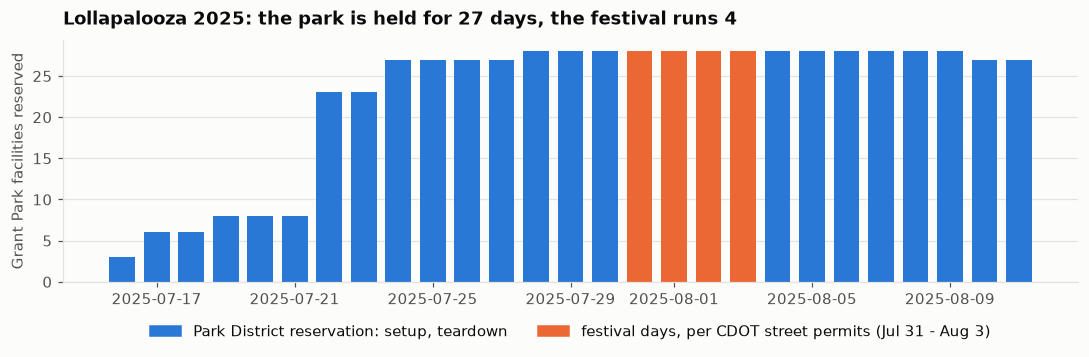

In [4]:
park = (pl.read_parquet(RAW / "park_permits.parquet")
        .filter(pl.col("event_description").str.to_uppercase().str.contains("LOLLAPALOOZA"))
        .with_columns(day=pl.col("reservation_start_date").str.to_datetime(strict=False).dt.date())
        .filter(pl.col("day").dt.year() == 2025)
        .group_by("day").agg(facilities=pl.col("park_facility_name").n_unique()).sort("day"))
street = held.filter((pl.col("category") == "festival") & (pl.col("start_date").dt.year() == 2025)
                     & pl.col("name").str.to_lowercase().str.contains("lollapalooza"))
start, end = street["start_date"].min(), street["end_date"].max()

from matplotlib.patches import Patch
on = [start <= d <= end for d in park["day"]]
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(park["day"], park["facilities"], color=[ORANGE if o else BLUE for o in on], width=0.75)
ax.set_title(f"Lollapalooza 2025: the park is held for {park.height} days, the festival runs {(end - start).days + 1}")
ax.set_ylabel("Grant Park facilities reserved")
ax.legend(handles=[Patch(color=BLUE, label="Park District reservation: setup, teardown"),
                   Patch(color=ORANGE, label=f"festival days, per CDOT street permits ({start:%b %-d} - {end:%b %-d})")],
          loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=2)
ax.grid(axis="x", visible=False)
fig.tight_layout()

**2. setlist.fm only has some of the shows.** It's crowd-sourced: a show appears only if a fan logged a
setlist. Schubas books most nights but shows a logged show on about a quarter of them. Unlogged shows end up
among the "no show" comparison nights, which pulls every club result toward 1.0. The chart also shows real
history: Double Door closed in 2017, and Sleeping Village and Avondale Music Hall opened later.

Share of 2022-2025 nights with a logged show:
┌────────────────┬─────────────────┐
│ place          ┆ share_of_nights │
│ ---            ┆ ---             │
│ str            ┆ f64             │
╞════════════════╪═════════════════╡
│ Thalia Hall    ┆ 0.441           │
│ Reggies        ┆ 0.366           │
│ Lincoln Hall   ┆ 0.332           │
│ Empty Bottle   ┆ 0.316           │
│ Beat Kitchen   ┆ 0.278           │
│ Schubas Tavern ┆ 0.274           │
└────────────────┴─────────────────┘


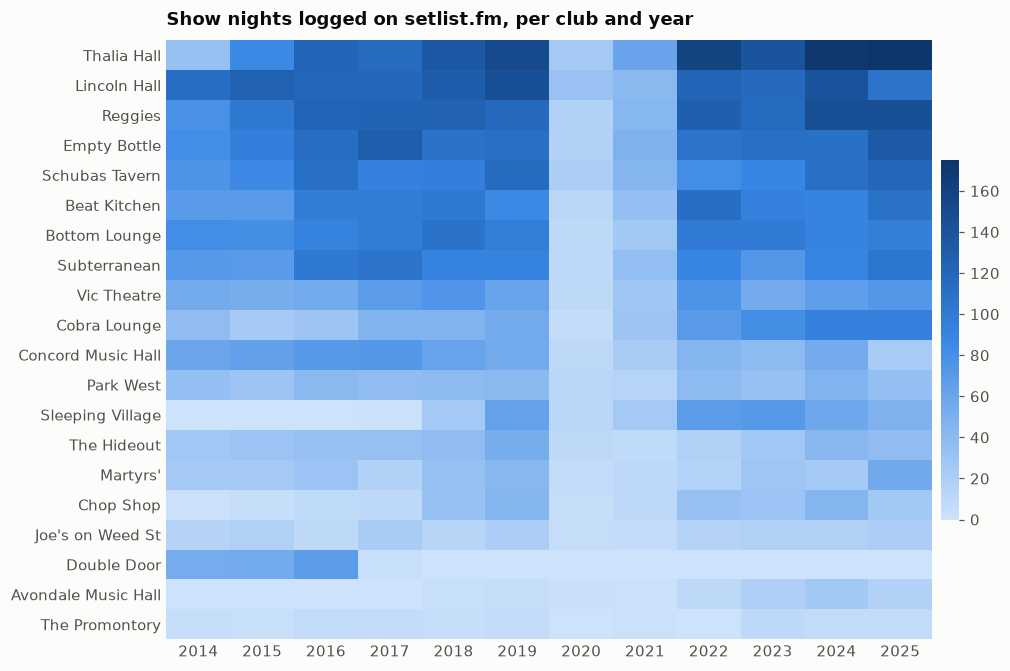

In [5]:
shows = held.filter(pl.col("source") == "setlistfm")
years = list(range(2014, 2026))
order = shows.group_by("place").len().sort("len", descending=True)["place"].to_list()
counts = shows.filter(pl.col("start_date").dt.year() <= 2025).group_by("place", year=pl.col("start_date").dt.year()).len()
M = np.zeros((len(order), len(years)))
for r in counts.iter_rows(named=True):
    M[order.index(r["place"]), years.index(r["year"])] = r["len"]

fig, ax = plt.subplots(figsize=(10, 6.2))
im = ax.imshow(M, cmap=SEQ_BLUE, aspect="auto", vmin=0)
ax.set_xticks(range(len(years)), years)
ax.set_yticks(range(len(order)), order)
ax.grid(False)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Show nights logged on setlist.fm, per club and year")
cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.01)
cb.outline.set_visible(False)
fig.tight_layout()

recent = shows.filter(pl.col("start_date").is_between(pl.date(2022, 1, 1), pl.date(2025, 12, 31)))
print("Share of 2022-2025 nights with a logged show:")
print(recent.group_by("place").agg((pl.len() / 1461).alias("share_of_nights")).sort("share_of_nights", descending=True).head(6))

**3. Ticketmaster is for the future only.** It returns zero events for any past week, so all history comes
from permits and setlist.fm. Some of its venue coordinates are wrong (it places the Empty Bottle in New York),
so its venues are matched to the clubs by street address. That address check also caught a mistake in the
club list: Concord Music Hall is at 2047 N Milwaukee, not 2351.

## 3. The design: observed vs. expected

For each event, the comparison is its own cells on the event day vs. the same cells on the same weekday in
nearby weeks:

```
 same weekday:   -4w    -3w    -2w    -1w   EVENT   +1w    +2w    +3w    +4w
                 ctrl   ctrl   ctrl   ctrl    ^     ctrl   ctrl   ctrl   ctrl
 expected = mean(clean control days in this cell) x city(event day) / mean(city on those control days)
```

- **Clean control days:** a control day is skipped if any event sits within one cell of it.
  - Permit events also rule out the day either side.
  - Club shows rule out only their own night, because the busiest clubs log a show on a third of nights.
- **The city scaling** absorbs holidays, weather and trend. July 4th is compared with how the whole city
  did on July 4th.
- **Rings:** the cells 1 and 2 steps out are scored the same way, to see how far an effect reaches.
- **Checks that should read ~1.0:** the day before, the day after, and a placebo date 5 weeks later.
- **Club shows** use the night (6pm-3am, keyed to the show's date) instead of the whole day, since setlist.fm
  has dates but no times.

Here is the raw version of that comparison, before the city scaling. It pools every event's own cells and
indexes to the average control week:

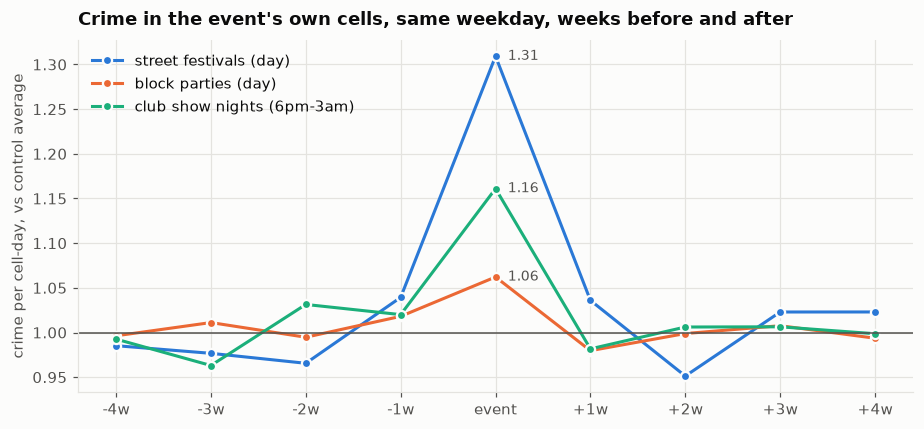

In [6]:
day_counts, day_known = load_counts(night=False)
night_counts, night_known = load_counts(night=True)
_, busy = busy_cell_days(events, cells)


def week_profile(evs, counts, known):
    """Crime in the events' own cells on the same weekday k weeks from each event day, per cell-day,
    as a share of the clean k = ±1..4 average. Only cell-days with 4+ clean control days count, so
    every k averages over the same places."""
    keys = event_cell_days(evs, cells).select("h3_r9", "date").unique()
    rows = (keys.join(pl.DataFrame({"k": list(range(-4, 5))}), how="cross")
            .with_columns(day=pl.col("date") + pl.duration(days=7 * pl.col("k")))
            .filter(pl.col("day").is_between(counts["date"].min(), known)))
    ctrl = rows.filter(pl.col("k") != 0).join(busy.rename({"date": "day"}), on=["h3_r9", "day"], how="anti")
    ok = ctrl.group_by("h3_r9", "date").len().filter(pl.col("len") >= 4).select("h3_r9", "date")
    rows = pl.concat([rows.filter(pl.col("k") == 0), ctrl]).join(ok, on=["h3_r9", "date"])
    prof = (rows.join(counts.rename({"date": "day"}).select("h3_r9", "day", "crime"), on=["h3_r9", "day"], how="left")
            .fill_null(0).group_by("k").agg(pl.mean("crime").alias("rate")).sort("k"))
    return prof.with_columns(index=pl.col("rate") / prof.filter(pl.col("k") != 0)["rate"].mean())


kinds = [("street festivals (day)", held.filter((pl.col("category") == "festival") & ~pl.col("long_run")), day_counts, day_known, BLUE),
         ("block parties (day)", held.filter(pl.col("category") == "block_party"), day_counts, day_known, ORANGE),
         ("club show nights (6pm-3am)", held.filter(pl.col("category") == "club_show"), night_counts, night_known, AQUA)]
fig, ax = plt.subplots(figsize=(8.5, 4))
for label, evs, counts, known, color in kinds:
    p = week_profile(evs, counts, known)
    ax.plot(p["k"], p["index"], "-o", color=color, ms=6, mec=SURFACE, mew=1.5, label=label)
    ax.annotate(f"{p.filter(pl.col('k') == 0)['index'][0]:.2f}", (0, p.filter(pl.col("k") == 0)["index"][0]),
                xytext=(8, 0), textcoords="offset points", va="center", color=INK_2, fontsize=9)
ax.axhline(1, color=INK_2, lw=1)
ax.set_xticks(range(-4, 5), ["-4w", "-3w", "-2w", "-1w", "event", "+1w", "+2w", "+3w", "+4w"])
ax.set_ylabel("crime per cell-day, vs control average")
ax.set_title("Crime in the event's own cells, same weekday, weeks before and after")
ax.legend(loc="upper left")
fig.tight_layout()

The event day stands out, and the weeks around it are flat. That flatness is what makes them usable as the
baseline. The pooled results below add the city scaling and a 90% interval (a Poisson bootstrap over events).

## 4. Permitted events

group,ratio,extra_crimes_per_event,expected_per_event
str,f64,f64,f64
"""festival, 5+ street segments""",1.524,1.327,2.531
"""festival, 2-4 segments""",1.196,0.165,0.842
"""festival, 1 segment""",1.259,0.112,0.433
"""all street festivals""",1.309,0.229,0.740
"""block parties""",1.063,0.010,0.154
"""parades""",0.957,-0.012,0.283
"""runs and walks (street)""",0.953,-0.027,0.560
"""rallies""",0.977,-0.017,0.770
"""Park District events""",1.072,0.020,0.280


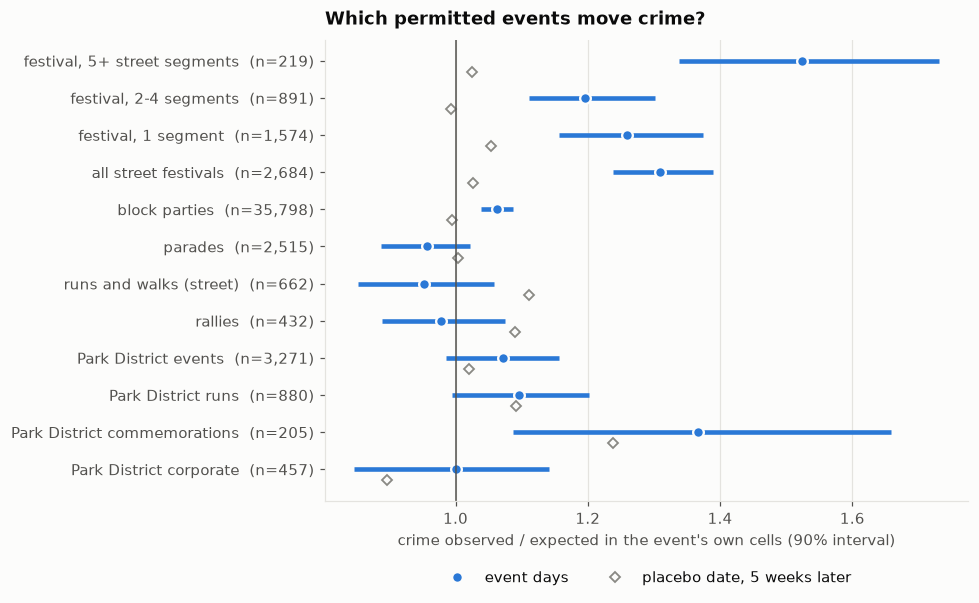

In [7]:
groups = [("festival: 5+ segments", "festival, 5+ street segments"), ("festival: 2-4 segments", "festival, 2-4 segments"),
          ("festival: 1 street segment", "festival, 1 segment"), ("festival", "all street festivals"),
          ("block_party", "block parties"), ("parade", "parades"), ("athletic", "runs and walks (street)"),
          ("assembly", "rallies"), ("park_event", "Park District events"), ("park_athletic", "Park District runs"),
          ("park_commemorative", "Park District commemorations"), ("park_corporate", "Park District corporate")]
ev = [pick(g) for g, _ in groups]
pb = [pick(g, timing="placebo_5wk") for g, _ in groups]

fig, ax = plt.subplots(figsize=(9, 5.6))
forest(ax, [f"{lab}  (n={r['n_events']:,})" for (_, lab), r in zip(groups, ev)],
       [r["ratio"] for r in ev], [r["lo90"] for r in ev], [r["hi90"] for r in ev], placebo=[r["ratio"] for r in pb])
ax.set_xlabel("crime observed / expected in the event's own cells (90% interval)")
ax.set_title("Which permitted events move crime?")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=2)
fig.tight_layout()

pl.DataFrame([{"group": lab, "ratio": r["ratio"], "extra_crimes_per_event": r["excess_per_event"],
               "expected_per_event": r["expected"] / r["n_events"]} for (_, lab), r in zip(groups, ev)])

- **Street festivals are the clear effect.** It grows with size: +52% for festivals closing 5+ segments.
  Their placebo dates sit near 1.0.
- **Block parties are +6%,** a small effect measured very precisely across ~36,000 of them.
- **Parades, runs and rallies show nothing clear.** Park District events show at most a small lift one cell
  out (+4%):
  - The biggest park festivals are multi-week reservations and get skipped. Their crowd days show up
    under street festivals instead, through their CDOT permits.
  - Park polygons also spread each event across the whole park.
  - Park District commemorations look high (1.37). But there are only ~200 of them, and their placebo
    runs high too (1.24), so that's likely noise.
- **In absolute terms these are modest.** Extra crimes per event run from ~0.01 (a block party) to ~1.3 (a
  big festival's own cells).

How far does it reach?

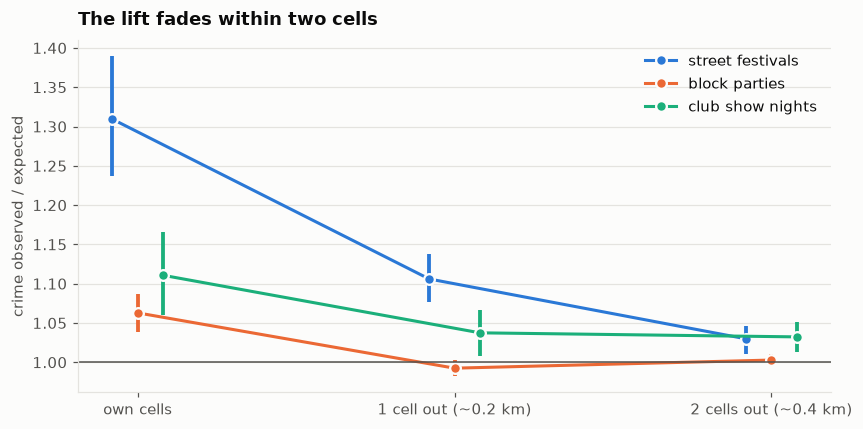

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for g, label, color, off in [("festival", "street festivals", BLUE, -0.08), ("block_party", "block parties", ORANGE, 0.0),
                             ("club_show", "club show nights", AQUA, 0.08)]:
    r = [pick(g, ring=k) for k in (0, 1, 2)]
    x = np.array([0, 1, 2]) + off
    ax.vlines(x, [q["lo90"] for q in r], [q["hi90"] for q in r], color=color, lw=2.5)
    ax.plot(x, [q["ratio"] for q in r], "-o", color=color, ms=7, mec=SURFACE, mew=1.5, label=label)
ax.axhline(1, color=INK_2, lw=1)
ax.set_xticks([0, 1, 2], ["own cells", "1 cell out (~0.2 km)", "2 cells out (~0.4 km)"])
ax.set_ylabel("crime observed / expected")
ax.set_title("The lift fades within two cells")
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False)
fig.tight_layout()

What kind of crime, and when? Street festivals:

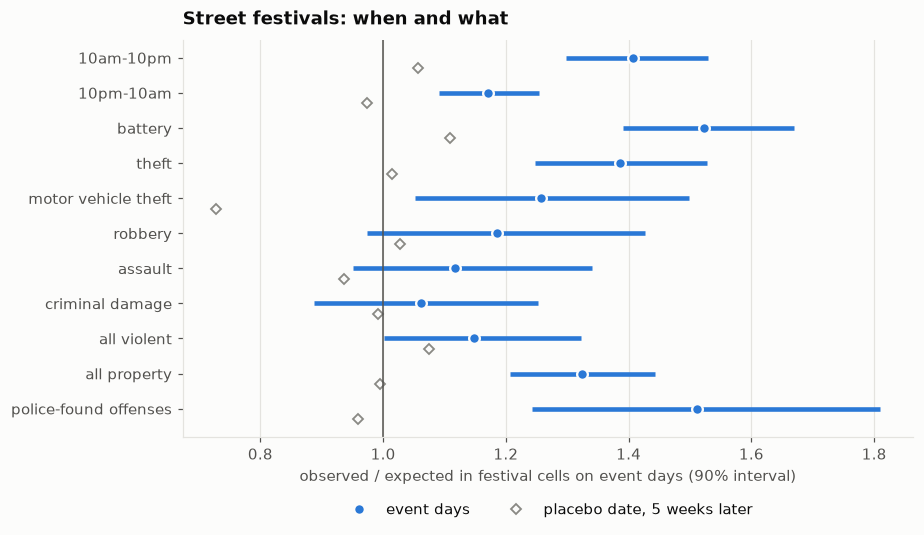

In [9]:
outs = [("crime_10am_10pm", "10am-10pm"), ("crime_10pm_10am", "10pm-10am"), ("battery", "battery"), ("theft", "theft"),
        ("motor_vehicle_theft", "motor vehicle theft"), ("robbery", "robbery"), ("assault", "assault"),
        ("criminal_damage", "criminal damage"), ("violent", "all violent"), ("property", "all property"),
        ("enforcement", "police-found offenses")]
ev = [pick("festival", o) for o, _ in outs]
pb = [pick("festival", o, timing="placebo_5wk") for o, _ in outs]
fig, ax = plt.subplots(figsize=(8.5, 5))
forest(ax, [lab for _, lab in outs], [r["ratio"] for r in ev], [r["lo90"] for r in ev], [r["hi90"] for r in ev],
       placebo=[r["ratio"] for r in pb])
ax.set_xlabel("observed / expected in festival cells on event days (90% interval)")
ax.set_title("Street festivals: when and what")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncols=2)
fig.tight_layout()

- **The lift is in the crowd's hours:** +41% between 10am and 10pm, against +17% overnight.
- **Battery and theft lead.** Motor vehicle theft rises too, probably parked cars in the neighborhood.
- **Police-found offenses rise the most** (+51%). Those are narcotics, weapons, public peace, liquor law,
  interference and prostitution, which police mostly find by being there. So that's partly just more officers
  on site. It's a reminder that recorded crime near events mixes the crowd's effect with the police response.

## 5. Club shows

slice,ratio,lo90,hi90,n_nights
str,f64,f64,f64,i64
"""6pm-midnight""",1.143,1.073,1.203,9280
"""midnight-3am""",1.033,0.939,1.133,9280
"""theft""",1.201,1.113,1.301,9280
"""battery""",1.118,0.986,1.245,9280
"""assault""",1.353,1.054,1.683,9280
"""headliner + openers""",1.068,0.990,1.159,3938
"""single act""",1.147,1.066,1.218,5342
"""Fri-Sat""",1.074,0.989,1.160,3216
"""Sun-Thu""",1.141,1.068,1.224,6064


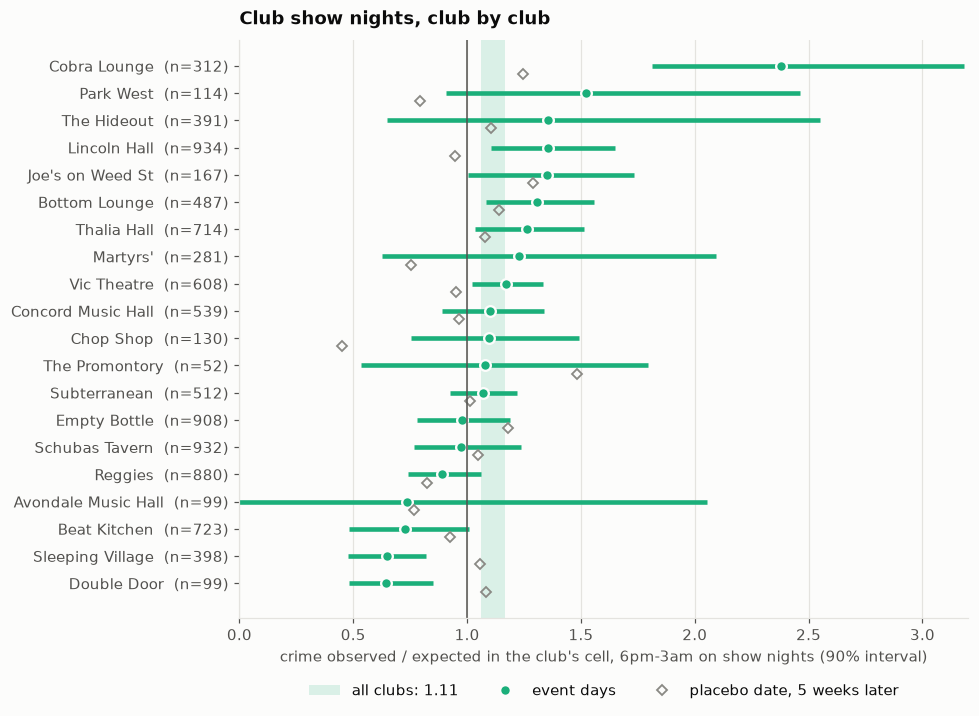

In [10]:
club_rows = (summary.filter((pl.col("outcome") == "crime") & (pl.col("ring") == 0) & (pl.col("timing") == "event")
                            & pl.col("group").str.starts_with("club: ") & ~pl.col("group").is_in(
                                ["club: 1 act", "club: 2+ acts", "club: Fri-Sat", "club: Sun-Thu"]))
             .sort("ratio", descending=True))
pb = {r["group"]: r["ratio"] for r in summary.filter((pl.col("outcome") == "crime") & (pl.col("ring") == 0)
                                                     & (pl.col("timing") == "placebo_5wk")).iter_rows(named=True)}
allc = pick("club_show")

fig, ax = plt.subplots(figsize=(9, 6.6))
ax.axvspan(allc["lo90"], allc["hi90"], color=AQUA, alpha=0.15, lw=0, label=f"all clubs: {allc['ratio']:.2f}")
forest(ax, [f"{g.removeprefix('club: ')}  (n={n:,})" for g, n in zip(club_rows["group"], club_rows["n_events"])],
       club_rows["ratio"], club_rows["lo90"], club_rows["hi90"], placebo=[pb[g] for g in club_rows["group"]], color=AQUA)
ax.set_xlabel("crime observed / expected in the club's cell, 6pm-3am on show nights (90% interval)")
ax.set_title("Club show nights, club by club")
ax.set_xlim(0, 3.2)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), ncols=3)
fig.tight_layout()

pl.DataFrame([{"slice": lab, "ratio": pick(g, o)["ratio"], "lo90": pick(g, o)["lo90"], "hi90": pick(g, o)["hi90"],
               "n_nights": pick(g, o)["n_events"]}
              for g, o, lab in [("club_show", "crime_6pm_midnight", "6pm-midnight"), ("club_show", "crime_midnight_3am", "midnight-3am"),
                                ("club_show", "theft", "theft"), ("club_show", "battery", "battery"), ("club_show", "assault", "assault"),
                                ("club: 2+ acts", "crime", "headliner + openers"), ("club: 1 act", "crime", "single act"),
                                ("club: Fri-Sat", "crime", "Fri-Sat"), ("club: Sun-Thu", "crime", "Sun-Thu")]])

- **Across all clubs, show nights run +11%.** Almost all of it falls before midnight, and it's mostly theft
  plus simple battery and assault.
- **Size proxies don't separate anything.** Headliner-plus-openers nights look like single-act nights, and
  weekends look like weeknights.
- **Per-club results are noisy.**
  - Vic, Bottom Lounge, Lincoln Hall and Thalia Hall sit clearly above 1.
  - Cobra Lounge's 2.4× is mostly theft and damage on the street, which looks like car break-ins during shows.
    Its placebo also runs high (1.25), though, so treat it as a lead.
  - Sleeping Village is *lower* on show nights.
  - Beyond chance, clubs differ less than this chart suggests. The look-ahead estimates a between-club spread
    of only ~0.10, so it pulls each club strongly toward the all-club average.

## 6. 311

Resident-reported 311 requests on event days, against the same placebo check:

In [11]:
pl.DataFrame([{"group": g, "outcome": o, "n_events": pick(g, o)["n_events"],
               "event_days": f"{pick(g, o)['ratio']:.2f} [{pick(g, o)['lo90']:.2f}-{pick(g, o)['hi90']:.2f}]",
               "placebo": round(pick(g, o, timing='placebo_5wk')["ratio"], 2)}
              for g, o in [("festival", "sr_resident"), ("festival: full closure", "sr_parking"), ("block_party", "sr_resident"),
                           ("parade", "sr_resident"), ("park_event", "sr_resident"), ("club_show", "sr_resident"),
                           ("club_show", "sr_business"), ("club_show", "sr_parking")]])

group,outcome,n_events,event_days,placebo
str,str,i64,str,f64
"""festival""","""sr_resident""",1661,"""1.08 [1.02-1.14]""",0.990
"""festival: full closure""","""sr_parking""",1013,"""1.64 [0.98-2.24]""",1.230
"""block_party""","""sr_resident""",19638,"""1.01 [0.98-1.04]""",0.970
"""parade""","""sr_resident""",1249,"""1.02 [0.93-1.12]""",1.050
"""park_event""","""sr_resident""",3277,"""1.03 [0.97-1.09]""",1.020
"""club_show""","""sr_resident""",5286,"""0.98 [0.90-1.08]""",0.880
"""club_show""","""sr_business""",5286,"""2.05 [1.43-2.89]""",0.880
"""club_show""","""sr_parking""",5286,"""1.54 [1.07-2.13]""",1.220


- **311 barely moves.** Festival cells run +8% (placebo 0.99), a whisper next to crime's +31%, and nothing
  else stands out.
- **One plausible lead:** business complaints double on club show nights (placebo 0.88). That's probably noise
  and crowd complaints about venues, but it rests on very few requests.

## 7. Checks, run live

Three checks:
1. **Consistency:** the pooled ratios re-derive from the per-event observed/expected table.
2. **Null calibration:** placebo dates and the days before and after events should behave like chance, so
   about 10% of their 90% intervals should exclude 1. This only holds with enough counts. With just a handful
   of expected incidents the bootstrap interval breaks down (zero observed gives a zero-width interval), so
   the check uses results with 20+ expected.
3. **No future in the look-ahead.** Score 2025's festivals as of 2024-12-31 twice:
   - once from the full tables;
   - once after deleting every crime from 2025 on and rebuilding the per-event history from what's left.

   The scores must be identical. (Permits for dates after the cutoff stay in both runs. They're filed in
   advance, so a real look-ahead would know about them.)

In [12]:
# 1. Pooled ratios re-derive from the per-event table.
oe = pl.read_parquet(EVENTS / "impact" / "oe_by_event.parquet")
oe_clubs = pl.read_parquet(EVENTS / "impact" / "oe_by_event_clubs.parquet")
for group, table in [("festival", oe), ("block_party", oe), ("parade", oe), ("club_show", oe_clubs)]:
    x = (table.filter((pl.col("ring") == 0) & (pl.col("timing") == "event"))
         .join(events.filter(pl.col("category") == group).select("event_id"), on="event_id"))
    ratio = x["O_crime"].sum() / x["E_crime"].sum()
    assert abs(ratio - pick(group)["ratio"]) < 1e-9, group
    print(f"consistency  {group:12} {x.height:>6,} events  ratio {ratio:.4f} matches the summary")

# 2. Null dates behave like chance, once there are enough counts for the interval to mean anything.
nulls = summary.filter(pl.col("timing").is_in(["placebo_5wk", "day_before", "day_after"]) & pl.col("lo90").is_not_nan())
for label, q in [("all", nulls), ("20+ expected", nulls.filter(pl.col("expected") >= 20))]:
    miss = ((q["lo90"] > 1) | (q["hi90"] < 1)).mean()
    print(f"null dates   {label:13} {q.height:>5,} intervals: {miss:5.1%} exclude 1.0 (chance: ~10%)")
assert 0.05 <= miss <= 0.15, miss

# 3. Scoring as of a date can't see past it.
from events_impact import CRIME_OUTCOMES, DAY_SPLITS, build_exposures, daily_counts, observed_expected
known = date(2024, 12, 31)
targets = held.filter((pl.col("category") == "festival") & ~pl.col("long_run") & (pl.col("start_date").dt.year() == 2025))
full, _, _ = festival_scores(targets, events, cells, oe, busy, day_counts, known)

outs = CRIME_OUTCOMES | DAY_SPLITS
crime_cut = daily_counts(CLEAN / "crimes.parquet", "occurred_at", outs,
                         ~pl.col("date_is_month_placeholder") & pl.col("occurred_at").is_between(
                             pl.datetime(2013, 11, 1), pl.datetime(2024, 12, 31, 23, 59, 59)))
expo, busy_expo = build_exposures(events, cells, ["cdot"])
fest_ids = held.filter(pl.col("category") == "festival")["event_id"].implode()
expo = expo.filter(pl.col("event_id").is_in(fest_ids) & (pl.col("ring") <= 1) & (pl.col("timing") == "event"))
oe_cut = observed_expected(expo, busy_expo, crime_cut, (crime_cut["date"].min(), known), list(outs))
cut, _, _ = festival_scores(targets, events, cells, oe_cut, busy, day_counts.filter(pl.col("date") <= known), known)

both = full.select("event_id", "extra_crime").join(cut.select("event_id", "extra_crime"), on="event_id", suffix="_cut")
assert both.height == targets.height and np.allclose(both["extra_crime"], both["extra_crime_cut"], rtol=1e-9, atol=1e-12)
print(f"no future    {both.height} festivals in 2025 score identically with every crime from 2025 on deleted")

consistency  festival      2,701 events  ratio 1.3094 matches the summary
consistency  block_party  36,038 events  ratio 1.0629 matches the summary
consistency  parade        2,519 events  ratio 0.9568 matches the summary
consistency  club_show     9,292 events  ratio 1.1107 matches the summary
null dates   all           1,922 intervals: 17.4% exclude 1.0 (chance: ~10%)
null dates   20+ expected    867 intervals:  9.1% exclude 1.0 (chance: ~10%)


no future    436 festivals in 2025 score identically with every crime from 2025 on deleted


## 8. The look-ahead

Each upcoming event is scored as **baseline × (ratio − 1)**:
- **Baseline:** crime normally expected in its cells and the ring around them over its dates. That's the
  same weekday within ±4 weeks of the same date, in each of the last 3 years, skipping days with an event
  nearby.
- **Ratio:** its own track record pooled with a prior (Gamma-Poisson).
  - Festivals: past editions of the same festival, with the average for festivals its size as the prior.
  - Club nights: the club's past show nights, with the all-club average as the prior.
- **How much weight history gets** comes from how much festivals (or clubs) truly differ beyond chance,
  estimated by method of moments. Festivals differ a lot (~0.45 around their size average, mostly pub
  crawls), so a festival with a few past editions mostly speaks for itself. Clubs differ little (~0.10), so
  a club's own record only nudges the all-club average.

The festivals come from CDOT permits already filed. The club nights come from the latest Ticketmaster snapshot.

festivals_2026-09-26.csv: 89 festivals, 48.3 extra crimes expected in total
club_nights_2026-09-26.csv: 353 club nights, 14.1 extra crimes expected in total


rank,start_date,n_days,name,community,n_segments,past_editions,baseline_crime,ratio_crime,extra [90%]
i64,date,i64,str,str,i64,i64,f64,f64,str
1,2027-03-13,1,"""The Shamrock Crawl""","""Lake View""",7,3,7.400,2.400,"""10.3 [6.9, 13.9]"""
2,2026-10-31,2,"""Wrigleyville Halloween Crawl""","""Lake View""",4,4,13.200,1.530,"""7.1 [1.5, 13.4]"""
3,2026-12-12,1,"""TBOX""","""Lake View""",4,6,5.500,1.950,"""5.2 [2.4, 8.4]"""
4,2026-10-02,3,"""Apple Fest 2026""","""Lincoln Square""",8,8,3.800,1.630,"""2.4 [0.3, 4.9]"""
5,2026-12-31,2,"""Wrigleyville NYE Crawl""","""Lake View""",1,4,4.700,1.460,"""2.2 [0.1, 4.6]"""
6,2026-10-03,2,"""Chicago Vintage Fest Pilsen""","""Lower West Side""",1,3,4.800,1.440,"""2.1 [-0.6, 5.4]"""
7,2026-11-14,2,"""Randolph Street Market""","""Near West Side""",4,8,5.900,1.230,"""1.4 [-0.1, 2.9]"""
8,2026-10-23,1,"""St. Clement Halloween 2026""","""Lincoln Park""",1,1,2.700,1.500,"""1.3 [-0.7, 3.9]"""
9,2026-09-26,2,"""Randolph Street Market""","""Near West Side""",4,8,5.100,1.230,"""1.2 [-0.0, 2.5]"""


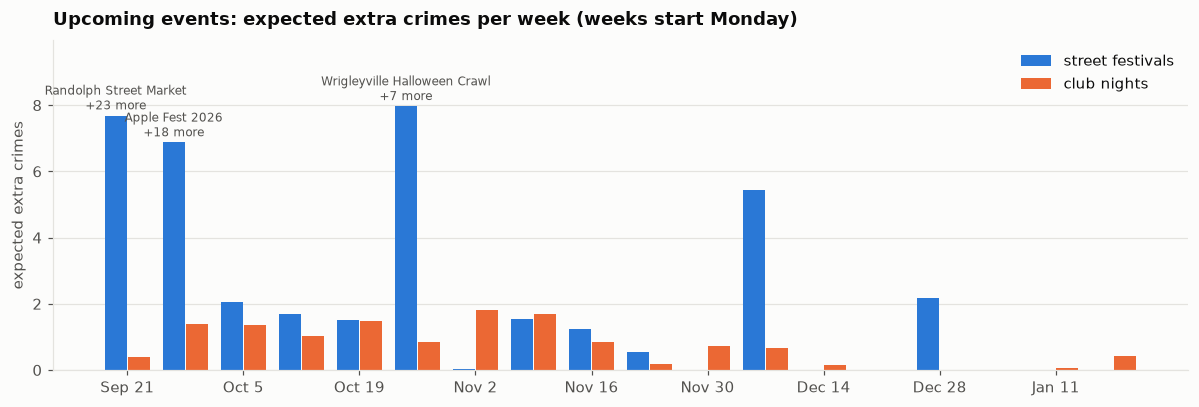

In [13]:
latest = lambda pattern: sorted(LOOKAHEAD.glob(pattern))[-1]
fest = pl.read_csv(latest("festivals_*.csv"), try_parse_dates=True)
nights = pl.read_csv(latest("club_nights_*.csv"), try_parse_dates=True)
print(f"{latest('festivals_*.csv').name}: {fest.height} festivals, {fest['extra_crime'].sum():.1f} extra crimes expected in total")
print(f"{latest('club_nights_*.csv').name}: {nights.height} club nights, {nights['extra_crime'].sum():.1f} extra crimes expected in total")

weekly = lambda df: df.group_by(pl.col("start_date").dt.truncate("1w").alias("week")).agg(pl.sum("extra_crime"))
first = min(fest["start_date"].min(), nights["start_date"].min())
weeks = pl.DataFrame({"week": pl.date_range(first - timedelta(days=first.weekday()), first + timedelta(weeks=17), "1w", eager=True)})
wf = weeks.join(weekly(fest), on="week", how="left").fill_null(0)
wc = weeks.join(weekly(nights), on="week", how="left").fill_null(0)

fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(weeks.height)
ax.bar(x - 0.2, wf["extra_crime"], width=0.38, color=BLUE, label="street festivals")
ax.bar(x + 0.2, wc["extra_crime"], width=0.38, color=ORANGE, label="club nights")
by_week = fest.with_columns(week=pl.col("start_date").dt.truncate("1w")).sort("extra_crime", descending=True)
for i in np.argsort(-wf["extra_crime"].to_numpy())[:3]:
    wk = by_week.filter(pl.col("week") == weeks["week"][int(i)])
    label = wk["name"][0] + (f"\n+{wk.height - 1} more" if wk.height > 1 else "")
    ax.annotate(label, (i - 0.2, wf["extra_crime"][int(i)]), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=8, color=INK_2)
ax.set_xticks(x[::2], [f"{w:%b %-d}" for w in weeks["week"]][::2])
ax.set_ylim(0, 1.25 * max(wf["extra_crime"].max(), wc["extra_crime"].max()))   # room for the labels
ax.set_ylabel("expected extra crimes")
ax.set_title("Upcoming events: expected extra crimes per week (weeks start Monday)")
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False)
fig.tight_layout()

fest.head(10).select("rank", "start_date", "n_days", "name", "community", "n_segments", "past_editions",
                     pl.col("baseline_crime").round(1), pl.col("ratio_crime").round(2),
                     pl.format("{} [{}, {}]", *[pl.col(c).round(1) for c in ("extra_crime", "extra_crime_lo", "extra_crime_hi")]).alias("extra [90%]"))

In [14]:
nights.group_by("place").agg(
    nights=pl.len(), through=pl.max("start_date"), club_ratio=pl.first("ratio_crime"),
    extra_per_night=pl.mean("extra_crime"), extra_total=pl.sum("extra_crime")).sort("extra_total", descending=True)

place,nights,through,club_ratio,extra_per_night,extra_total
str,u32,date,f64,f64,f64
"""Bottom Lounge""",35,2027-02-19,1.219,0.200,6.995
"""Vic Theatre""",57,2027-05-26,1.113,0.092,5.254
"""Joe's on Weed St""",16,2027-01-22,1.111,0.098,1.569
"""Subterranean""",22,2027-03-10,1.057,0.048,1.055
"""Empty Bottle""",64,2027-05-09,1.033,0.014,0.895
"""Thalia Hall""",65,2027-04-27,1.014,0.010,0.665
"""Park West""",10,2027-04-04,1.105,0.026,0.263
"""Lincoln Hall""",3,2027-03-20,1.114,0.057,0.171
"""Chop Shop""",5,2026-11-13,1.038,0.024,0.119


- **Festivals:** Wrigleyville pub crawls lead on their own record (the Shamrock Crawl has run 2.4× its
  baseline), then big closures in busy areas.
- **Club nights matter in bulk.** A single night adds at most ~0.2 crimes, but the Bottom Lounge's and the
  Vic's seasons each add up to about as much as a big festival.
- **Coverage gaps:**
  - The festival list covers only permits already filed, which is mostly this fall.
  - Clubs that don't sell through Ticketmaster (Sleeping Village, Martyrs', Cobra Lounge, the Hideout, the
    Promontory) are missing from the club list.

## 9. Does the look-ahead work? The backtest

Each year 2017–2025 is replayed as of January 1st through the same scoring code (section 7 checks it can't
see the future). "Actual extra crime" is a festival's observed crime minus the controlled expected count from
section 4. Four rankings are compared, each within its year:
- **full:** the look-ahead as it ships.
- **no history:** the size prior only, ignoring a festival's past editions.
- **baseline only:** how much crime the area normally has on those dates.
- **size only:** the number of street segments.

2,212 festival-years, 1105 actual extra crimes; the shipped model predicted 1217


ranking,spearman,top_20%_captures,top_O/E,rest_O/E
str,f64,f64,f64,f64
"""full""",0.075,0.740,1.271,1.088
"""no_history""",0.054,0.691,1.218,1.123
"""baseline_only""",0.042,0.668,1.202,1.140
"""size_only""",0.082,0.622,1.279,1.110


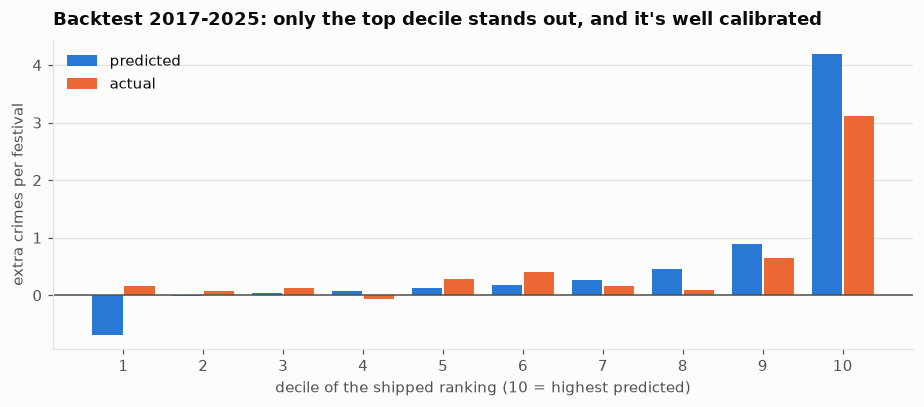

In [15]:
from scipy.stats import spearmanr
from events_backtest import MODELS, TOP_SHARE, top_mask

bt = pl.read_csv(LOOKAHEAD / "backtest.csv")
actual, O, E = bt["actual"].to_numpy(), bt["actual_O"].to_numpy(), bt["actual_E"].to_numpy()
rows = []
for m in MODELS:
    t = top_mask(bt, m)
    rows.append({"ranking": m, "spearman": spearmanr(bt[m].to_numpy(), actual).statistic,
                 f"top_{TOP_SHARE:.0%}_captures": actual[t].sum() / actual.sum(),
                 "top_O/E": O[t].sum() / E[t].sum(), "rest_O/E": O[~t].sum() / E[~t].sum()})
print(f"{bt.height:,} festival-years, {actual.sum():.0f} actual extra crimes; "
      f"the shipped model predicted {bt['full'].sum():.0f}")
display(pl.DataFrame(rows))

dec = (bt.with_columns(decile=(pl.col("full").rank(method="ordinal") * 10 / (pl.len() + 1)).floor().cast(pl.Int8) + 1)
       .group_by("decile").agg(predicted=pl.mean("full"), actual=pl.mean("actual")).sort("decile"))
fig, ax = plt.subplots(figsize=(8.5, 3.8))
x = dec["decile"].to_numpy()
ax.bar(x - 0.2, dec["predicted"], width=0.38, color=BLUE, label="predicted")
ax.bar(x + 0.2, dec["actual"], width=0.38, color=ORANGE, label="actual")
ax.axhline(0, color=INK_2, lw=1)
ax.set_xticks(x, [f"{d}" for d in x])
ax.set_xlabel("decile of the shipped ranking (10 = highest predicted)")
ax.set_ylabel("extra crimes per festival")
ax.set_title("Backtest 2017-2025: only the top decile stands out, and it's well calibrated")
ax.legend(loc="upper left")
ax.grid(axis="x", visible=False)
fig.tight_layout()

- **The totals are about right:** 1,217 predicted over nine years, against 1,105 actual. Single years swing a lot.
- **The top decile holds most of the effect, a little over-predicted.** It predicts about 4.2 extra crimes per
  festival, 3.1 happened, and that decile holds 62% of all the actual extra crime.
- **Below the top decile, the order is weak.** Rank correlation with the outcome is 0.04–0.08 for every ranking.
- **History helps a little.** The full ranking's top 20% captures 74%, against 69% for size priors alone and 67%
  for baseline alone. Both paired intervals still reach zero (`events_backtest.py`).
- **So the list works as a short filter:** pub crawls and big closures on busy corridors are where extra
  incidents land. Don't read meaning into the order below the top 10–20%.

## 10. What we learned, and what's next

**What the numbers say:**
1. **Crowds bring some crime with them, where they are and while they're there.** Street festivals: +31%
   in their own cells, mostly daytime theft and battery. Club nights: +11% before midnight. Block parties:
   +6%. All of it fades within ~0.4 km.
2. **The absolute numbers are modest.** A big festival adds about 2.5 crimes, and a busy club's season about
   as much.
3. **311 carries at most a whisper of an event signal,** plus a thin lead on business complaints near clubs.
4. **Looking ahead works as a filter.** Most of the extra crime lands at a few events: pub crawls and the
   biggest closures in the busiest places.

**Worth trying next:**
- **Collect Ticketmaster snapshots daily.** It has no history, but saved snapshots become one, with start times
  that setlist.fm lacks.
- **Get calendars for the clubs Ticketmaster misses** (Sleeping Village, Martyrs', Cobra Lounge).
- **Check Cobra Lounge's street thefts** against vehicle break-in descriptions, to confirm the car break-in
  reading.
- **Bring the festival filter into the app,** as "upcoming events nearby" on the area detail view.

**Caveats:**
- **Recorded crime mixes the crowd with the police response.** More officers at an event means more offenses
  found and more thefts reported on the spot.
- **Unlogged club shows** sit among the comparison nights, so the club effect is probably understated.
- **About 1,600 pooled ratios** were computed, so expect a few extremes by chance. Trust the results that also
  pass the placebo, timing and distance checks, as the festival, block-party and club results do.
- **Intervals on tiny counts aren't reliable.** Below ~20 expected incidents, read a ratio as a hint, not a
  finding.
- **Big parks dilute.** A permit names the park, not where in it the event is.